# Task 1: Deep Learning


## Team Members and Contributions

| Member | Name | Student ID | Contribution | Individual Contribution Factor |
|---|---|---|---|---|
| 1 | Waralee Sidokmai | 105089004 | Dataset preprocessing and final review | 1.0 |
| 2 | Name 2 | TBC | Deep Learning model | 1.0 |
| 3 | Name 3 | TBC | Deep Learning evaluation and DL vs ML comparison | 1.0 |
| 4 | Name 4 | TBC | Machine Learning feature extraction | 1.0 |
| 5 | Name 5 | TBC | Machine Learning model and hyperparameter tuning | 1.0 |
| 6 | Name 6 | TBC | Machine Learning evaluation and appendix support | 1.0 |


## 1. Dataset Loading and Preprocessing

This section loads and preprocesses the CIFAR-10 dataset by checking the official train/test split, displaying sample images, normalizing image data, preparing labels, and handing the prepared variables to the next sections.

The same CIFAR-10 train/test split should also be used in the ML notebook so the final DL vs ML comparison is fair.


### 1.1 Import Libraries and Set Up


In [5]:
from pathlib import Path
import pickle
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
DATA_DIR = Path("data")
ARCHIVE_PATH = DATA_DIR / "cifar-10-python.tar.gz"
EXTRACTED_DIR = DATA_DIR / "cifar-10-batches-py"

### 1.2 Download and Extract CIFAR-10


In [7]:
def download_cifar10():
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    if EXTRACTED_DIR.exists():
        print("CIFAR-10 already extracted")
        return

    if not ARCHIVE_PATH.exists():
        print("Downloading CIFAR-10...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
        print("Download complete")

    print("Extracting CIFAR-10...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR)

    print("Extraction complete")

download_cifar10()

CIFAR-10 already extracted


### 1.3 Load CIFAR-10 Data


In [9]:
def unpickle(file_path):
    with open(file_path, "rb") as file:
        data = pickle.load(file, encoding="latin1")
    return data

def load_cifar10():
    train_images = []
    train_labels = []

    for batch_number in range(1, 6):
        batch_path = EXTRACTED_DIR / f"data_batch_{batch_number}"
        batch = unpickle(batch_path)

        images = batch["data"]
        labels = batch["labels"]

        # CIFAR-10 stores each image as a flat array. Reshape it to 32 x 32 RGB format.
        images = images.reshape(-1, 3, 32, 32)
        images = images.transpose(0, 2, 3, 1)

        train_images.append(images)
        train_labels.append(labels)

    test_batch = unpickle(EXTRACTED_DIR / "test_batch")

    x_train = np.concatenate(train_images)
    y_train = np.concatenate(train_labels)

    x_test = test_batch["data"]
    y_test = np.array(test_batch["labels"])

    x_test = x_test.reshape(-1, 3, 32, 32)
    x_test = x_test.transpose(0, 2, 3, 1)

    meta = unpickle(EXTRACTED_DIR / "batches.meta")
    class_names = meta["label_names"]

    return x_train, y_train, x_test, y_test, class_names

x_train, y_train, x_test, y_test, class_names = load_cifar10()

print("CIFAR-10 data loaded")

CIFAR-10 data loaded


### 1.4 Check Dataset Information


In [11]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

print("\nNumber of classes:", len(class_names))
print("Class names:", class_names)

print("\nClass distribution:")
for class_id, class_name in enumerate(class_names):
    train_count = np.sum(y_train == class_id)
    test_count = np.sum(y_test == class_id)
    print(f"{class_name}: train={train_count}, test={test_count}")

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000,)

Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Class distribution:
airplane: train=5000, test=1000
automobile: train=5000, test=1000
bird: train=5000, test=1000
cat: train=5000, test=1000
deer: train=5000, test=1000
dog: train=5000, test=1000
frog: train=5000, test=1000
horse: train=5000, test=1000
ship: train=5000, test=1000
truck: train=5000, test=1000


### 1.5 Display Sample Images


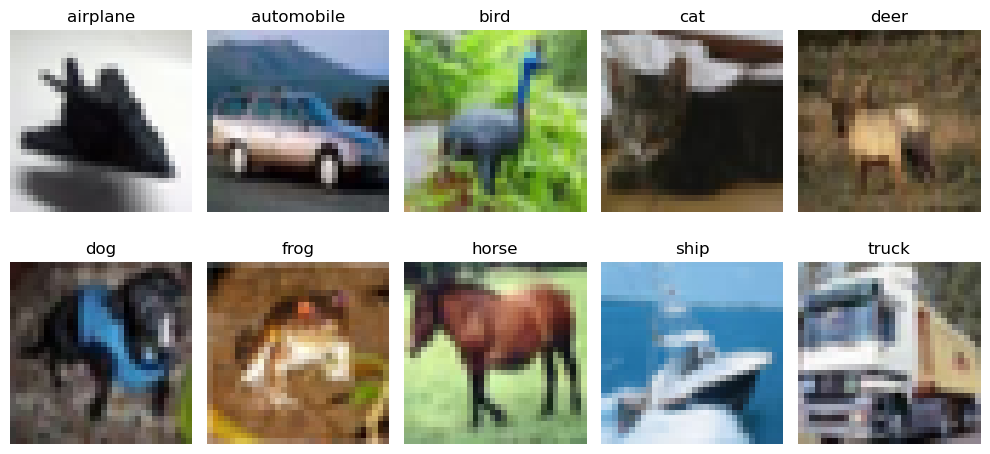

In [13]:
plt.figure(figsize=(10, 5))

for i in range(10):
    # Display one training image from each CIFAR-10 class.
    class_index = np.where(y_train == i)[0][0]
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[class_index], interpolation="nearest")
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

CIFAR-10 images are low resolution because each image is only 32 x 32 pixels.


### 1.6 Normalize Data


In [16]:
# Normalize pixel values from 0-255 to 0-1 for neural network training.
x_train_normalized = x_train.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

print("Training data min:", x_train_normalized.min())
print("Training data max:", x_train_normalized.max())
print("Testing data min:", x_test_normalized.min())
print("Testing data max:", x_test_normalized.max())

Training data min: 0.0
Training data max: 1.0
Testing data min: 0.0
Testing data max: 1.0


The image pixel values were normalized from 0-255 to 0-1 so the model receives input values on a smaller and consistent scale.


### 1.7 Prepare Labels


In [19]:
# Keep labels as integer class IDs for sparse categorical loss or CrossEntropyLoss.
y_train_labels = y_train.copy()
y_test_labels = y_test.copy()

print("Training labels shape:", y_train_labels.shape)
print("Testing labels shape:", y_test_labels.shape)
print("Example labels:", y_train_labels[:10])

Training labels shape: (50000,)
Testing labels shape: (10000,)
Example labels: [6 9 9 4 1 1 2 7 8 3]


### 1.8 Final Preprocessing Check


In [21]:
print("Final training data shape:", x_train_normalized.shape)
print("Final testing data shape:", x_test_normalized.shape)
print("Final training labels shape:", y_train_labels.shape)
print("Final testing labels shape:", y_test_labels.shape)

print("\nData type:", x_train_normalized.dtype)
print("Number of classes:", len(class_names))

assert x_train_normalized.shape == (50000, 32, 32, 3)
assert x_test_normalized.shape == (10000, 32, 32, 3)
assert y_train_labels.shape == (50000,)
assert y_test_labels.shape == (10000,)
assert x_train_normalized.min() >= 0 and x_train_normalized.max() <= 1
assert x_test_normalized.min() >= 0 and x_test_normalized.max() <= 1
assert len(class_names) == 10

print("Preprocessing check passed")

Final training data shape: (50000, 32, 32, 3)
Final testing data shape: (10000, 32, 32, 3)
Final training labels shape: (50000,)
Final testing labels shape: (10000,)

Data type: float32
Number of classes: 10
Preprocessing check passed


### 1.9 Prepared Data for Deep Learning Model


In [23]:
x_train_dl = x_train_normalized
x_test_dl = x_test_normalized
y_train_dl = y_train_labels
y_test_dl = y_test_labels

print("x_train_dl:", x_train_dl.shape)
print("x_test_dl:", x_test_dl.shape)
print("y_train_dl:", y_train_dl.shape)
print("y_test_dl:", y_test_dl.shape)

x_train_dl: (50000, 32, 32, 3)
x_test_dl: (10000, 32, 32, 3)
y_train_dl: (50000,)
y_test_dl: (10000,)


## 2. Deep Learning Model


## 3. Deep Learning Evaluation and Final DL vs ML Comparison
